In [1]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!pip install -q kaggle kagglehub

In [3]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"gaurichorge","key":"a140ebe97f7eeabced701e68767f62f9"}'}

In [4]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.copy("kaggle (1).json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)

In [5]:
import kagglehub


path = kagglehub.dataset_download("techsash/waste-classification-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'waste-classification-data' dataset.
Path to dataset files: /kaggle/input/waste-classification-data


In [6]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print(files[:5])

/kaggle/input/waste-classification-data
[]
/kaggle/input/waste-classification-data/DATASET
[]
/kaggle/input/waste-classification-data/DATASET/TEST
[]
/kaggle/input/waste-classification-data/DATASET/TEST/R
['R_10683.jpg', 'R_10736.jpg', 'R_10489.jpg', 'R_10512.jpg', 'R_10975.jpg']
/kaggle/input/waste-classification-data/DATASET/TEST/O
['O_13927.jpg', 'O_12651.jpg', 'O_13771.jpg', 'O_13720.jpg', 'O_13446.jpg']
/kaggle/input/waste-classification-data/DATASET/TRAIN
[]
/kaggle/input/waste-classification-data/DATASET/TRAIN/R
['R_6214.jpg', 'R_8141.jpg', 'R_2463.jpg', 'R_9892.jpg', 'R_5469.jpg']
/kaggle/input/waste-classification-data/DATASET/TRAIN/O
['O_5670.jpg', 'O_1764.jpg', 'O_9501.jpg', 'O_364.jpg', 'O_5301.jpg']
/kaggle/input/waste-classification-data/dataset
[]
/kaggle/input/waste-classification-data/dataset/DATASET
[]
/kaggle/input/waste-classification-data/dataset/DATASET/TEST
[]
/kaggle/input/waste-classification-data/dataset/DATASET/TEST/R
['R_10683.jpg', 'R_10736.jpg', 'R_10489.j

Image Path: /kaggle/input/waste-classification-data/DATASET/TEST/R/R_10683.jpg


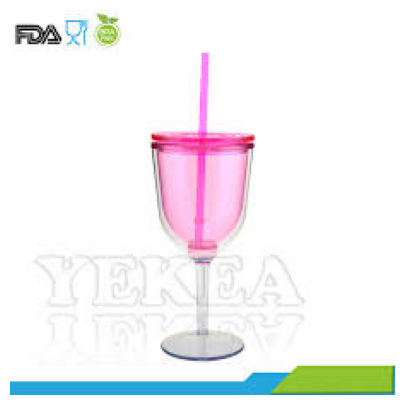

In [7]:
import os
import cv2
import matplotlib.pyplot as plt

image_path = None

# Find the first image in the dataset
for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_path = os.path.join(root, file)
            break
    if image_path:
        break

print("Image Path:", image_path)

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

In [8]:
import os

for root, dirs, files in os.walk(path):
    print(root)

/kaggle/input/waste-classification-data
/kaggle/input/waste-classification-data/DATASET
/kaggle/input/waste-classification-data/DATASET/TEST
/kaggle/input/waste-classification-data/DATASET/TEST/R
/kaggle/input/waste-classification-data/DATASET/TEST/O
/kaggle/input/waste-classification-data/DATASET/TRAIN
/kaggle/input/waste-classification-data/DATASET/TRAIN/R
/kaggle/input/waste-classification-data/DATASET/TRAIN/O
/kaggle/input/waste-classification-data/dataset
/kaggle/input/waste-classification-data/dataset/DATASET
/kaggle/input/waste-classification-data/dataset/DATASET/TEST
/kaggle/input/waste-classification-data/dataset/DATASET/TEST/R
/kaggle/input/waste-classification-data/dataset/DATASET/TEST/O
/kaggle/input/waste-classification-data/dataset/DATASET/TRAIN
/kaggle/input/waste-classification-data/dataset/DATASET/TRAIN/R
/kaggle/input/waste-classification-data/dataset/DATASET/TRAIN/O


In [9]:
import kagglehub

path = kagglehub.dataset_download("techsash/waste-classification-data")
print(path)

Using Colab cache for faster access to the 'waste-classification-data' dataset.
/kaggle/input/waste-classification-data


In [10]:
import os

print("Exists:", os.path.exists(path))
print(os.listdir(path))

Exists: True
['DATASET', 'dataset']


In [14]:
import os
import shutil
import kagglehub

# Download datasets
tech_path = kagglehub.dataset_download("techsash/waste-classification-data")
garbage_path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")

# ---------------- Find TRAIN folder ----------------

tech_train = None
for root, dirs, files in os.walk(tech_path):
    if os.path.basename(root) == "TRAIN":
        tech_train = root
        break

# ---------------- Find trash folder ----------------

trash_path = None
for root, dirs, files in os.walk(garbage_path):
    if os.path.basename(root).lower() == "trash":
        trash_path = root
        break

print("Tech Train:", tech_train)
print("Trash:", trash_path)

# ---------------- Create new dataset ----------------

new_dataset = "./WasteDataset"

bio = os.path.join(new_dataset, "Biodegradable")
rec = os.path.join(new_dataset, "Recyclable")
non = os.path.join(new_dataset, "Non_Recyclable")

os.makedirs(bio, exist_ok=True)
os.makedirs(rec, exist_ok=True)
os.makedirs(non, exist_ok=True)

# Copy Organic -> Biodegradable
for img in os.listdir(os.path.join(tech_train, "O")):
    shutil.copy(
        os.path.join(tech_train, "O", img),
        os.path.join(bio, img)
    )

# Copy Recyclable
for img in os.listdir(os.path.join(tech_train, "R")):
    shutil.copy(
        os.path.join(tech_train, "R", img),
        os.path.join(rec, img)
    )

# Copy Trash -> Non_Recyclable
for img in os.listdir(trash_path):
    shutil.copy(
        os.path.join(trash_path, img),
        os.path.join(non, img)
    )

print("Dataset Created Successfully!")

Using Colab cache for faster access to the 'waste-classification-data' dataset.


100%|██████████| 82.0M/82.0M [00:00<00:00, 128MB/s]

Extracting files...


Tech Train: /kaggle/input/waste-classification-data/DATASET/TRAIN
Trash: /root/.cache/kagglehub/datasets/asdasdasasdas/garbage-classification/versions/2/Garbage classification/Garbage classification/trash
Dataset Created Successfully!


In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train.flow_from_directory(
    "/content/WasteDataset",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_data = train.flow_from_directory(
    "/content/WasteDataset",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Found 18162 images belonging to 3 classes.
Found 4539 images belonging to 3 classes.


In [16]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,GlobalAveragePooling2D

base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base.trainable=False

model=Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256,activation="relu"),
    Dropout(0.3),
    Dense(3,activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,691 (9.87 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [18]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [19]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
568/568 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8841 - loss: 0.3127
Epoch 1: val_accuracy improved from None to 0.93941, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
568/568 ━━━━━━━━━━━━━━━━━━━━ 83s 112ms/step - accuracy: 0.9111 - loss: 0.2379 - val_accuracy: 0.9394 - val_loss: 0.1718
Epoch 2/30
567/568 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9424 - loss: 0.1517
Epoch 2: val_accuracy improved from 0.93941 to 0.94712, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
568/568 ━━━━━━━━━━━━━━━━━━━━ 34s 59ms/step - accuracy: 0.9425 - loss: 0.1517 - val_accuracy: 0.9471 - val_loss: 0.1505
Epoch 3/30
567/568 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9544 - loss: 0.1225
Epoch 3: val_accuracy did not improve from 0.94712
568/568 ━━━━━━━━━━━━━━━━━━━━ 36s 64ms/step - accuracy: 0.9539 - loss: 0.1213 - val_accuracy: 0.9299 - val_loss: 0.1803
Epoch 4/30
568/568 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/ste

In [20]:
model.save("SmartWasteClassifier.h5")

In [23]:
import os

test_path = "/kaggle/input/waste-classification-data/DATASET/TEST"

print(os.listdir(test_path))

['R', 'O']


In [25]:
import os

image_path = None

for root, dirs, files in os.walk("/kaggle/input/waste-classification-data"):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_path = os.path.join(root, file)
            break
    if image_path:
        break

print(image_path)

/kaggle/input/waste-classification-data/DATASET/TEST/R/R_10683.jpg


In [26]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img(image_path, target_size=(224,224))
img = image.img_to_array(img)
img = np.expand_dims(img, axis=0) / 255.0

prediction = model.predict(img)

class_names = list(train_data.class_indices.keys())

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Prediction:", predicted_class)
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Prediction: Recyclable
Confidence: 96.30%


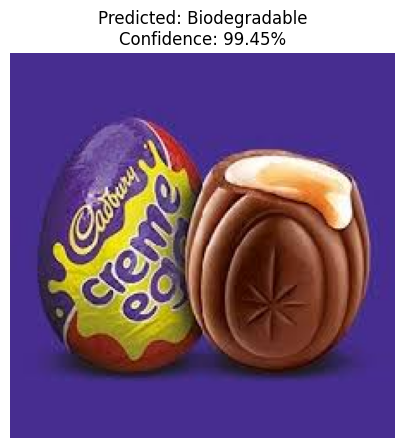

Actual Class    : Biodegradable
Predicted Class : Biodegradable
Confidence      : 99.45%


In [30]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Select a random image from your dataset
test_folder = "/content/WasteDataset"   # Change if your dataset is elsewhere

# Get all class folders
classes = os.listdir(test_folder)

# Choose a random class
chosen_class = random.choice(classes)

# Choose a random image from that class
img_name = random.choice(os.listdir(os.path.join(test_folder, chosen_class)))

img_path = os.path.join(test_folder, chosen_class, img_name)

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Display image
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")

# Preprocess image
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Predict
prediction = model.predict(img_array, verbose=0)

# Get class names from training generator
class_names = list(train_data.class_indices.keys())

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# Display result
plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.show()

print("Actual Class    :", chosen_class)
print("Predicted Class :", predicted_class)
print(f"Confidence      : {confidence:.2f}%")